In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pyod.utils.data import generate_data
from pyod.utils.example import visualize

from iforest import BAD_IForest
from pyod.models.iforest import IForest

X_train, X_test, y_train, y_test = generate_data(
    n_train=1000, n_test=100, contamination=0.1, random_state=0
)
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)
bforest = BAD_IForest().fit(X_train)
iforest = IForest().fit(X_train)

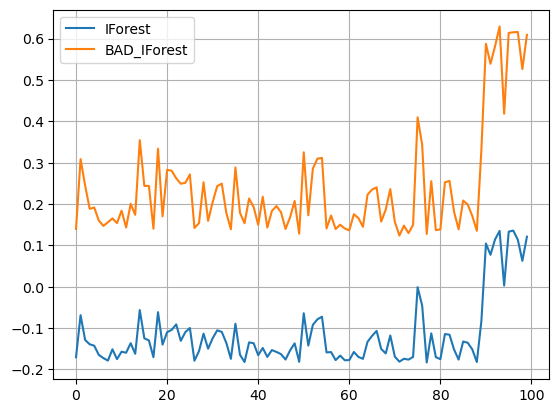

In [2]:
bforest = BAD_IForest().fit(X_train)
iforest = IForest().fit(X_train)
plt.plot(iforest.decision_function(X_test), label='IForest')
plt.plot(bforest.decision_function(X_test), label='BAD_IForest')
plt.legend()
plt.grid()
plt.show()

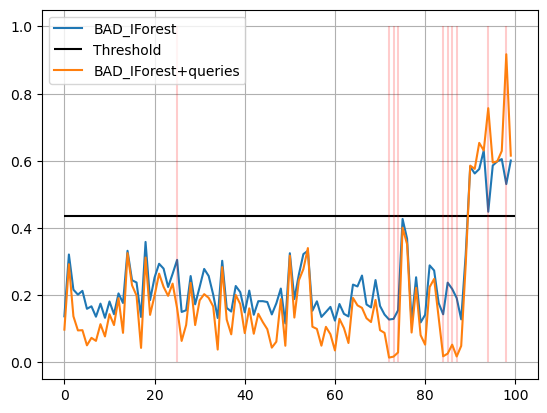

In [3]:
bforest = BAD_IForest().fit(X_train)
plt.plot(bforest.decision_function(X_test), label='BAD_IForest')
plt.hlines(bforest.threshold_, 0, len(X_test), "k", label='Threshold')

queriable = np.ones(len(X_test), dtype=bool)
for i in range(10):
    i = bforest.get_queries(X_test[queriable], 1)
    bforest.update(X_test[i], y_test[i])
    queriable[i] = False

    plt.vlines(i, 0, 1, "r", alpha=0.2)
plt.plot(bforest.decision_function(X_test), label='BAD_IForest+queries')
plt.legend()
plt.grid()
plt.show()

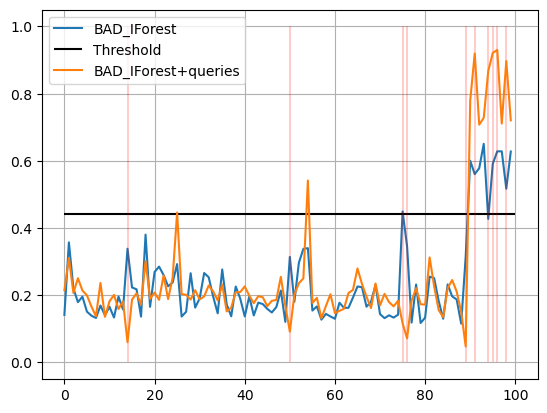

In [4]:
bforest = BAD_IForest().fit(X_train)
plt.plot(bforest.decision_function(X_test), label='BAD_IForest')
plt.hlines(bforest.threshold_, 0, len(X_test), "k", label='Threshold')
i = bforest.get_queries(X_test, 10)
bforest.update(X_test[i], y_test[i])
plt.vlines(i, 0, 1, "r", alpha=0.2)
plt.plot(bforest.decision_function(X_test), label='BAD_IForest+queries')
plt.legend()
plt.grid()
plt.show()

In [5]:
print("IForest fit time:")
%timeit IForest().fit(X_train)
print("IForest predict time:")
%timeit iforest.decision_function(X_test)

IForest fit time:
103 ms ± 9.05 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
IForest predict time:
1.38 ms ± 16.8 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [6]:
print("BAD_IForest fit time:")
%timeit BAD_IForest(reprocess_decision_scores=False).fit(X_train)
print("BAD_IForest predict time:")
%timeit bforest.decision_function(X_train)

print("BAD_IForest interest time:")
%timeit bforest.interest(X_train)
print("BAD_IForest update time:")
%timeit bforest.update(X_train, y_train)
print("BAD_IForest batch_query time:")
%timeit bforest.get_queries(X_train, 10)

BAD_IForest fit time:
110 ms ± 4.16 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
BAD_IForest predict time:
4.68 ms ± 25.8 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
BAD_IForest interest time:
5.29 ms ± 188 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
BAD_IForest update time:
28.7 ms ± 1.42 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
BAD_IForest batch_query time:
1min 8s ± 2.4 s per loop (mean ± std. dev. of 7 runs, 1 loop each)
